In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.base import clone

In [2]:
DATA_PATH = "../../data/pr_review_traces/processed/final_security_patch.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 29)


,repo_name,pr_number,pr_title,pr_body,pr_state,pr_created_at,pr_updated_at,pr_merged_at,pr_merge_commit_sha,pr_additions,...,line,original_line,side,start_line,original_start_line,author_association,comment_created_at,comment_updated_at,security_label,label_notes
0,grommet/hpe-design-system,5159,add datafilters wcag,<!--- Provide a general summary of the PR in t...,closed,2025-05-13T05:06:52Z,2025-05-20T00:28:06Z,2025-05-20T00:28:06Z,ed2105adad46b12a9272c15d35f3aaee6a47026b,1040,...,NaN,6,RIGHT,NaN,NaN,COLLABORATOR,2025-05-15T18:22:15Z,2025-05-15T18:22:15Z,0,No security-relevant topic found in the commen...
1,appsmithorg/appsmith,39646,feat: implement table widget infinite scroll w...,## Description\r\nThis PR adds support for var...,closed,2025-03-10T08:00:48Z,2025-03-21T10:14:18Z,2025-03-20T09:23:37Z,c162311f43efe652627cdf1b950d7eb7419043e8,594,...,NaN,55,RIGHT,NaN,38.0,CONTRIBUTOR,2025-03-19T05:22:40Z,2025-03-19T05:28:15Z,1,Labeled 1: comment/diff references a security-...
2,adorsys/status-list-server,55,feat: add keypair generation to startup logic,NaN,closed,2025-04-24T12:13:50Z,2025-05-23T09:31:36Z,2025-05-23T09:31:33Z,35084ed00253b0d082124e96014502a4f340667b,351,...,NaN,99,RIGHT,NaN,NaN,COLLABORATOR,2025-05-05T15:48:29Z,2025-05-05T16:15:35Z,1,Labeled 1: comment/diff contains a clear secur...
3,vinteumorg/Floresta,402,Re-structured functional tests.,Improves https://github.com/vinteumorg/Florest...,closed,2025-03-07T14:34:25Z,2025-03-12T16:19:02Z,2025-03-12T16:19:02Z,443bf8defd0b7a370d267e6253ec2d4291a496bb,447,...,330.0,330,RIGHT,NaN,NaN,MEMBER,2025-03-10T15:48:21Z,2025-03-10T15:48:21Z,1,Labeled 1: comment/diff contains a clear secur...
4,vacanza/holidays,2502,Update India holidays: add missing Tamil Nadu ...,<!--\r\n Thanks for contributing to holidays!...,closed,2025-04-26T14:04:29Z,2025-05-05T18:10:53Z,2025-04-28T20:20:40Z,5f154404cac9bee763b2cbafa2e9e15ef993741c,155,...,905.0,905,RIGHT,869.0,869.0,CONTRIBUTOR,2025-04-26T16:36:43Z,2025-04-26T16:36:44Z,0,No security-relevant topic found in the commen...


In [3]:
print("Columns:")

for column in df.columns:
    print("-", column)

Columns:
- repo_name
- pr_number
- pr_title
- pr_body
- pr_state
- pr_created_at
- pr_updated_at
- pr_merged_at
- pr_merge_commit_sha
- pr_additions
- pr_deletions
- pr_changed_files
- comment_id
- review_id
- review_comment
- diff_hunk
- file_path
- commit_id
- original_commit_id
- line
- original_line
- side
- start_line
- original_start_line
- author_association
- comment_created_at
- comment_updated_at
- security_label
- label_notes


In [4]:
print("Security label distribution:")
print(df["security_label"].value_counts().sort_index())

Security label distribution:
security_label
0    2930
1    1073
2     997
Name: count, dtype: int64


In [5]:
df_binary = df[df["security_label"].isin([0, 1])].copy()

df_binary["security_label"] = df_binary["security_label"].astype(int)

print("Binary dataset shape:", df_binary.shape)

print("\nBinary label distribution:")
print(df_binary["security_label"].value_counts().sort_index())

Binary dataset shape: (4003, 29)

Binary label distribution:
security_label
0    2930
1    1073
Name: count, dtype: int64


In [6]:
print("Missing diff hunks:", df_binary["diff_hunk"].isna().sum())

print(
    "Empty diff hunks:",
    (df_binary["diff_hunk"].fillna("").str.strip() == "").sum()
)

Missing diff hunks: 0
Empty diff hunks: 0


In [7]:
def clean_patch(text):
    if pd.isna(text):
        return ""

    text = str(text)

    lines = text.splitlines()
    cleaned_lines = []

    for line in lines:

        # Remove diff metadata
        if line.startswith("@@"):
            continue

        if line.startswith("+++"):
            continue

        if line.startswith("---"):
            continue

        # Added code
        if line.startswith("+"):
            cleaned_lines.append("ADD " + line[1:])

        # Deleted code
        elif line.startswith("-"):
            cleaned_lines.append("DEL " + line[1:])

        # Context code
        else:
            cleaned_lines.append("CTX " + line)

    return "\n".join(cleaned_lines)

In [8]:
df_binary["patch_text"] = df_binary["diff_hunk"].apply(clean_patch)

print(df_binary["patch_text"].head())

0    ADD [\nADD   {\nADD     "rule": "1.1.1",\nADD ...
1    ADD import { useEffect, type RefObject } from ...
2    CTX      pub fn to_pkcs8_pem(&self) -> Result<...
3    CTX  \nCTX  Additional functional tests are av...
4    CTX          2035: (SEP, 14),\nCTX      }\nCTX...
Name: patch_text, dtype: str


In [9]:
example_patch = df_binary.iloc[0]

print("Repository:")
print(example_patch["repo_name"])

print("\nPR:")
print(example_patch["pr_number"])

print("\nFile:")
print(example_patch["file_path"])

print("\nOriginal Diff:")
print(example_patch["diff_hunk"])

print("\nCleaned Patch:")
print(example_patch["patch_text"])

Repository:
grommet/hpe-design-system

PR:
5159

File:
aries-site/src/data/wcag/datafilters.json

Original Diff:
@@ -0,0 +1,512 @@
+[
+  {
+    "rule": "1.1.1",
+    "label": "Non-text content",
+    "status": "conditional",
+    "notes": "if using Layer for datafilters then Layer with a close icon must provide an aria-label or alternative text unless the icon is purely decorative"

Cleaned Patch:
ADD [
ADD   {
ADD     "rule": "1.1.1",
ADD     "label": "Non-text content",
ADD     "status": "conditional",
ADD     "notes": "if using Layer for datafilters then Layer with a close icon must provide an aria-label or alternative text unless the icon is purely decorative"


In [10]:
df_binary["pr_group"] = (
    df_binary["repo_name"].astype(str)
    + "#"
    + df_binary["pr_number"].astype(str)
)

print("Unique PR groups:", df_binary["pr_group"].nunique())

Unique PR groups: 2762


In [11]:
X = df_binary["patch_text"]
y = df_binary["security_label"]
groups = df_binary["pr_group"]

print("Number of samples:", len(X))
print("Number of PR groups:", groups.nunique())

print("\nClass distribution:")
print(y.value_counts().sort_index())

Number of samples: 4003
Number of PR groups: 2762

Class distribution:
security_label
0    2930
1    1073
Name: count, dtype: int64


In [12]:
tfidf_params = {
    "lowercase": True,
    "stop_words": "english",
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "sublinear_tf": True
}

print(tfidf_params)

{'lowercase': True, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True}


In [13]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        max_features="sqrt"
    )
}

In [14]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [15]:
def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

In [16]:
fold_results = []
oof_predictions = []

for model_name, model in models.items():

    print(f"\nRunning: {model_name}")

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X, y, groups),
        start=1
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        # Fit TF-IDF only on training data
        vectorizer = TfidfVectorizer(
            **tfidf_params
        )

        X_train_tfidf = vectorizer.fit_transform(
            X_train
        )

        X_val_tfidf = vectorizer.transform(
            X_val
        )

        print(
            f"  Fold {fold}: "
            f"TF-IDF train shape = {X_train_tfidf.shape}"
        )

        # Clone and train model
        clf = clone(model)

        clf.fit(
            X_train_tfidf,
            y_train
        )

        # Predict validation data
        y_pred = clf.predict(
            X_val_tfidf
        )

        # Calculate metrics
        metrics = calculate_metrics(
            y_val,
            y_pred
        )

        fold_results.append({
            "model": model_name,
            "fold": fold,
            "train_samples": len(train_idx),
            "validation_samples": len(val_idx),
            "train_groups": groups.iloc[train_idx].nunique(),
            "validation_groups": groups.iloc[val_idx].nunique(),
            **metrics
        })

        # Store out-of-fold predictions
        fold_predictions = df_binary.iloc[
            val_idx
        ][
            [
                "repo_name",
                "pr_number",
                "comment_id",
                "review_comment",
                "diff_hunk",
                "file_path",
                "security_label"
            ]
        ].copy()

        fold_predictions["model"] = model_name
        fold_predictions["fold"] = fold
        fold_predictions["prediction"] = y_pred

        oof_predictions.append(
            fold_predictions
        )

        print(
            f"  Accuracy={metrics['accuracy']:.4f}, "
            f"Balanced Accuracy={metrics['balanced_accuracy']:.4f}, "
            f"Precision={metrics['precision']:.4f}, "
            f"Recall={metrics['recall']:.4f}, "
            f"F1={metrics['f1']:.4f}"
        )


Running: Logistic Regression
  Fold 1: TF-IDF train shape = (3200, 63126)
  Accuracy=0.8232, Balanced Accuracy=0.7986, Precision=0.6492, Recall=0.7454, F1=0.6940
  Fold 2: TF-IDF train shape = (3203, 67439)
  Accuracy=0.8650, Balanced Accuracy=0.8470, Precision=0.7208, Recall=0.8084, F1=0.7621
  Fold 3: TF-IDF train shape = (3203, 69864)
  Accuracy=0.8400, Balanced Accuracy=0.7855, Precision=0.7150, Recall=0.6682, F1=0.6908
  Fold 4: TF-IDF train shape = (3203, 62932)
  Accuracy=0.8688, Balanced Accuracy=0.8274, Precision=0.7633, Recall=0.7383, F1=0.7506
  Fold 5: TF-IDF train shape = (3203, 67303)
  Accuracy=0.8762, Balanced Accuracy=0.8360, Precision=0.7816, Recall=0.7488, F1=0.7648

Running: Linear SVM
  Fold 1: TF-IDF train shape = (3200, 63126)
  Accuracy=0.8705, Balanced Accuracy=0.8178, Precision=0.7917, Recall=0.7037, F1=0.7451
  Fold 2: TF-IDF train shape = (3203, 67439)
  Accuracy=0.8925, Balanced Accuracy=0.8510, Precision=0.8232, Recall=0.7617, F1=0.7913
  Fold 3: TF-IDF t

In [17]:
fold_metrics = pd.DataFrame(
    fold_results
)

fold_metrics

,model,fold,train_samples,validation_samples,train_groups,validation_groups,accuracy,balanced_accuracy,precision,recall,f1
0,Logistic Regression,1,3200,803,2204,558,0.823163,0.798580,0.649194,0.745370,0.693966
1,Logistic Regression,2,3203,800,2223,539,0.865000,0.847038,0.720833,0.808411,0.762115
2,Logistic Regression,3,3203,800,2201,561,0.840000,0.785477,0.715000,0.668224,0.690821
3,Logistic Regression,4,3203,800,2201,561,0.868750,0.827350,0.763285,0.738318,0.750594
4,Logistic Regression,5,3203,800,2219,543,0.876250,0.835957,0.781553,0.748837,0.764846
5,Linear SVM,1,3200,803,2204,558,0.870486,0.817780,0.791667,0.703704,0.745098
6,Linear SVM,2,3203,800,2223,539,0.892500,0.850978,0.823232,0.761682,0.791262
7,Linear SVM,3,3203,800,2201,561,0.867500,0.798316,0.817647,0.649533,0.723958
8,Linear SVM,4,3203,800,2201,561,0.878750,0.825277,0.812834,0.710280,0.758105
9,Linear SVM,5,3203,800,2219,543,0.892500,0.830888,0.877193,0.697674,0.777202


In [18]:
cv_summary = (
    fold_metrics
    .groupby("model")
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean"
        ),

        balanced_accuracy_std=(
            "balanced_accuracy",
            "std"
        ),

        precision_mean=(
            "precision",
            "mean"
        ),

        precision_std=(
            "precision",
            "std"
        ),

        recall_mean=(
            "recall",
            "mean"
        ),

        recall_std=(
            "recall",
            "std"
        ),

        f1_mean=(
            "f1",
            "mean"
        ),

        f1_std=(
            "f1",
            "std"
        )
    )
    .reset_index()
)

cv_summary

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Linear SVM,0.880347,0.011835,0.824648,0.019191,0.824515,0.031777,0.704575,0.039912,0.759125,0.026429
1,Logistic Regression,0.854633,0.022240,0.818880,0.025904,0.725973,0.051292,0.741832,0.049812,0.732468,0.036989
2,Random Forest,0.890342,0.013799,0.814655,0.024814,0.915305,0.023957,0.651490,0.050044,0.760297,0.035571


In [19]:
cv_summary_rounded = cv_summary.copy()

metric_columns = [
    "accuracy_mean",
    "accuracy_std",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "precision_mean",
    "precision_std",
    "recall_mean",
    "recall_std",
    "f1_mean",
    "f1_std"
]

cv_summary_rounded[metric_columns] = (
    cv_summary_rounded[metric_columns]
    .round(4)
)

cv_summary_rounded

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Linear SVM,0.8803,0.0118,0.8246,0.0192,0.8245,0.0318,0.7046,0.0399,0.7591,0.0264
1,Logistic Regression,0.8546,0.0222,0.8189,0.0259,0.7260,0.0513,0.7418,0.0498,0.7325,0.0370
2,Random Forest,0.8903,0.0138,0.8147,0.0248,0.9153,0.0240,0.6515,0.0500,0.7603,0.0356


In [20]:
oof_df = pd.concat(
    oof_predictions,
    ignore_index=True
)

print(
    "OOF prediction rows:",
    len(oof_df)
)

print(
    "\nRows per model:"
)

print(
    oof_df.groupby("model").size()
)

OOF prediction rows: 12009

Rows per model:
model
Linear SVM             4003
Logistic Regression    4003
Random Forest          4003
dtype: int64


In [21]:
OUTPUT_DIR = "../../data/pr_review_traces/processed/patch_ml_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

fold_metrics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "patch_only_fold_metrics.csv"
    ),
    index=False
)

cv_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "patch_only_cv_summary.csv"
    ),
    index=False
)

oof_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "patch_only_oof_predictions.csv"
    ),
    index=False
)

print(
    "Results saved to:",
    OUTPUT_DIR
)

Results saved to: ../../data/pr_review_traces/processed/patch_ml_results


In [22]:
confusion_results = {}

for model_name in models.keys():

    model_oof = oof_df[
        oof_df["model"] == model_name
    ]

    cm = confusion_matrix(
        model_oof["security_label"],
        model_oof["prediction"],
        labels=[0, 1]
    )

    confusion_results[
        model_name
    ] = cm

    print(
        f"\n{model_name}"
    )

    print(cm)


Logistic Regression
[[2625  305]
 [ 277  796]]

Linear SVM
[[2768  162]
 [ 317  756]]

Random Forest
[[2865   65]
 [ 374  699]]


In [23]:
for model_name, cm in confusion_results.items():

    confusion_df = pd.DataFrame(
        cm,
        index=[
            "Actual 0",
            "Actual 1"
        ],
        columns=[
            "Predicted 0",
            "Predicted 1"
        ]
    )

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    confusion_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            f"confusion_patch_only_{safe_name}.csv"
        )
    )

print("Confusion matrices saved.")

Confusion matrices saved.


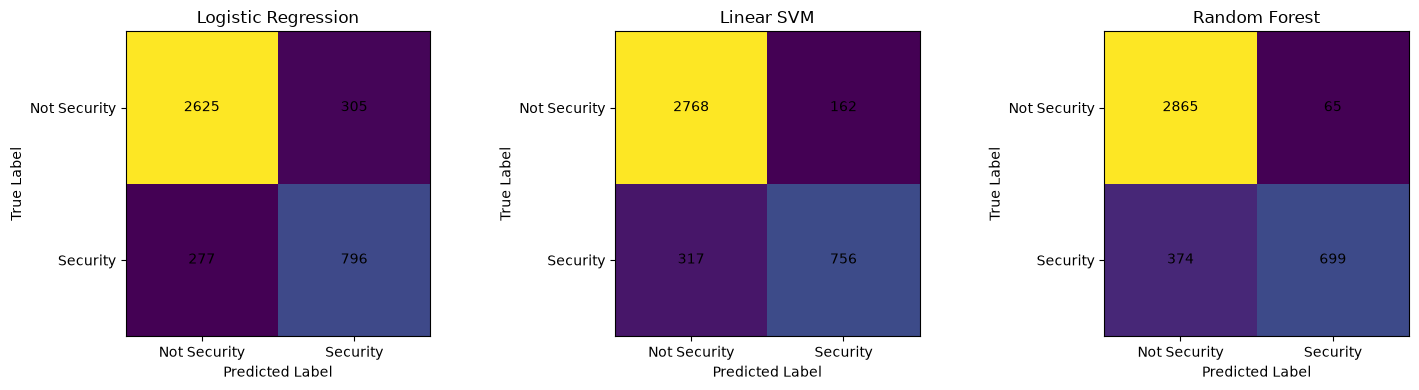

In [24]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for ax, (model_name, cm) in zip(
    axes,
    confusion_results.items()
):

    ax.imshow(cm)

    ax.set_title(model_name)

    ax.set_xlabel(
        "Predicted Label"
    )

    ax.set_ylabel(
        "True Label"
    )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(
        [
            "Not Security",
            "Security"
        ]
    )

    ax.set_yticklabels(
        [
            "Not Security",
            "Security"
        ]
    )

    for i in range(2):
        for j in range(2):

            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

plt.tight_layout()
plt.show()

In [25]:
error_cases = []

for model_name in models.keys():

    model_oof = oof_df[
        oof_df["model"] == model_name
    ].copy()

    model_oof["error_type"] = "Correct"

    model_oof.loc[
        (
            (model_oof["security_label"] == 0)
            &
            (model_oof["prediction"] == 1)
        ),
        "error_type"
    ] = "False Positive"

    model_oof.loc[
        (
            (model_oof["security_label"] == 1)
            &
            (model_oof["prediction"] == 0)
        ),
        "error_type"
    ] = "False Negative"

    errors = model_oof[
        model_oof["error_type"] != "Correct"
    ].copy()

    error_cases.append(
        errors
    )

error_cases_df = pd.concat(
    error_cases,
    ignore_index=True
)

print(
    error_cases_df[
        "error_type"
    ].value_counts()
)

error_type
False Negative    968
False Positive    532
Name: count, dtype: int64


In [26]:
error_counts_by_model = (
    error_cases_df
    .groupby(
        [
            "model",
            "error_type"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

error_counts_by_model

error_type,False Negative,False Positive
model,,
Linear SVM,317,162
Logistic Regression,277,305
Random Forest,374,65


In [27]:
false_positives = error_cases_df[
    error_cases_df["error_type"]
    == "False Positive"
].copy()

print(
    "False positives:",
    len(false_positives)
)

false_positives[
    [
        "model",
        "repo_name",
        "pr_number",
        "comment_id",
        "review_comment",
        "diff_hunk",
        "file_path",
        "security_label",
        "prediction"
    ]
].head(20)

False positives: 532


,model,repo_name,pr_number,comment_id,review_comment,diff_hunk,file_path,security_label,prediction
1,Logistic Regression,langchain4j/langchain4j-community,59,2021042948,done,"@@ -0,0 +1,39 @@\n+package dev.langchain4j.dat...",document-parsers/langchain4j-document-parser-l...,0,1
3,Logistic Regression,goauthentik/authentik,13586,2014506012,```suggestion\r\n#\r\n# You may edit the gener...,"@@ -1,5 +1,17 @@\n-# update website/docs/insta...",authentik/lib/default.yml,0,1
4,Logistic Regression,naukmagymdb/gym,46,2064044399,"a сорі, я забув що у нас такі є вимоги, так то...","@@ -0,0 +1,105 @@\n+import { ConflictException...",packages/backend/src/products/products.service.ts,0,1
7,Logistic Regression,statsig-io/docs,2854,2036022980,"The ""Notes"" and ""References"" sections currentl...","@@ -0,0 +1,99 @@\n+---\n+title: Geotests\n+sid...",docs/statsig-warehouse-native/geotests/introdu...,0,1
9,Logistic Regression,elastic/elasticsearch,126091,2041283443,"Yep, naming is hard :) I'll update.","@@ -0,0 +1,175 @@\n+/*\n+ * Copyright Elastics...",server/src/main/java/org/elasticsearch/cluster...,0,1
10,Logistic Regression,ImperialCollegeLondon/imperial_coldfront_plugin,216,2079351617,Well spotted!,"@@ -631,3 +641,50 @@ def task_stat_view(reques...",imperial_coldfront_plugin/views.py,0,1
11,Logistic Regression,cognitedata/dotnet-simulator-utils,239,1975028429,"agreed, removed this from here","@@ -0,0 +1,226 @@\n+using System;\n+using Syst...",Cognite.Simulator.Utils/LicenseController.cs,0,1
13,Logistic Regression,leanprover/lean-action,122,2056057490,:bulb: Thanks for clarifying!,"@@ -0,0 +1,70 @@\n+name: 'Reinstall Transient ...",.github/functional_tests/reinstall-transient-t...,0,1
14,Logistic Regression,FinOps-Open-Cost-and-Usage-Spec/FOCUS_Spec,830,2003393218,Capitalization on `co`,"@@ -0,0 +1,89 @@\n+# SaaS Spend Agreements\n+\...",specification/appendix/saas_examples/spend_agr...,0,1
18,Logistic Regression,debezium/debezium.github.io,1133,2100610214,```suggestion\r\nYou also use https://github.c...,"@@ -0,0 +1,438 @@\n+---\n+layout: post\n+title...",_posts/2025-05-22-debezium-as-part-of-your-ai-...,0,1


In [28]:
false_negatives = error_cases_df[
    error_cases_df["error_type"]
    == "False Negative"
].copy()

print(
    "False negatives:",
    len(false_negatives)
)

false_negatives[
    [
        "model",
        "repo_name",
        "pr_number",
        "comment_id",
        "review_comment",
        "diff_hunk",
        "file_path",
        "security_label",
        "prediction"
    ]
].head(20)

False negatives: 968


,model,repo_name,pr_number,comment_id,review_comment,diff_hunk,file_path,security_label,prediction
0,Logistic Regression,Argus-Labs/world-cli,143,2056914921,logic: processRepoToken no longer handles 'pub...,"@@ -440,25 +441,17 @@ func (p *project) prompt...",cmd/world/forge/project.go,1,0
2,Logistic Regression,hashintel/hash,6880,2031894558,unused import: `HashSet`\n\n[Show more details...,"@@ -103,14 +142,18 @@\n #[expect(clippy::panic...",libs/@local/graph/authorization/src/policies/a...,1,0
5,Logistic Regression,1024pix/pix,12268,2084893227,Les fichiers sont plutôt nommés en Kebab-case ...,"@@ -22,6 +21,7 @@ import { certificationSessio...",api/server.js,1,0
6,Logistic Regression,causify-ai/helpers,374,1999651519,Are 39-46 still needed then?\r\n\r\nLet's try ...,"@@ -48,8 +50,9 @@ jobs:\n id: login-ec...",.github/workflows/fast_tests.yml,1,0
8,Logistic Regression,opendatahub-io/opendatahub-tests,175,1999354657,`if _upgrade_deployment_modes` -> need to retu...,"@@ -102,19 +123,45 @@ def pytest_collection_mo...",conftest.py,1,0
12,Logistic Regression,bcgov/lear,3523,2116877801,Thanks! Was just running into this starting to...,"@@ -24,3 +23,14 @@ git+https://github.com/bcgo...",queue_services/entity-digital-credentials/requ...,1,0
15,Logistic Regression,shopinvader/odoo-shopinvader,1574,1875832296,```suggestion\r\n address_type: Address...,"@@ -120,49 +126,121 @@ def get_delivery_addres...",shopinvader_api_address/routers/address_servic...,1,0
16,Logistic Regression,elastic/elasticsearch,124144,1982115326,We don't need to be recreating the object on e...,"@@ -38,16 +56,13 @@ public String inferenceEnt...",x-pack/plugin/inference/src/main/java/org/elas...,1,0
17,Logistic Regression,OpenRA/OpenRA,21830,2020130838,```\r\nif (c.IsBot && !map.TryGetMessage(c.Nam...,"@@ -425,14 +428,27 @@ public static void Setup...",OpenRA.Mods.Common/Widgets/Logic/Lobby/LobbyUt...,1,0
19,Logistic Regression,scalableminds/webknossos,8147,2035208149,_🛠️ Refactor suggestion_\n\n_⚠️ Potential issu...,"@@ -1,13 +1,272 @@\n name: CI Pipeline\n \n on...",.github/workflows/build_test_deploy.yml,1,0


In [29]:
error_cases_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "patch_only_false_positive_false_negative_cases.csv"
    ),
    index=False
)

print(
    "False-positive and false-negative cases saved."
)

False-positive and false-negative cases saved.


In [30]:
for model_name in models.keys():

    model_oof = oof_df[
        oof_df["model"] == model_name
    ]

    print(
        "\n" + "=" * 70
    )

    print(
        model_name
    )

    print(
        "=" * 70
    )

    print(
        classification_report(
            model_oof["security_label"],
            model_oof["prediction"],
            target_names=[
                "Not Security",
                "Security"
            ],
            digits=4,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

Not Security     0.9045    0.8959    0.9002      2930
    Security     0.7230    0.7418    0.7323      1073

    accuracy                         0.8546      4003
   macro avg     0.8138    0.8189    0.8162      4003
weighted avg     0.8559    0.8546    0.8552      4003


Linear SVM
              precision    recall  f1-score   support

Not Security     0.8972    0.9447    0.9204      2930
    Security     0.8235    0.7046    0.7594      1073

    accuracy                         0.8803      4003
   macro avg     0.8604    0.8246    0.8399      4003
weighted avg     0.8775    0.8803    0.8772      4003


Random Forest
              precision    recall  f1-score   support

Not Security     0.8845    0.9778    0.9288      2930
    Security     0.9149    0.6514    0.7610      1073

    accuracy                         0.8903      4003
   macro avg     0.8997    0.8146    0.8449      4003
weighted avg     0.8927   